In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
# Shows all columns
pd.set_option("display.max_columns", None)

# Neptune's average distance from the sun (AU)
NEPTUNE_AVERAGE_DISTANCE = 30.1


# Open the dataset
with open("Datasets/distant_extended.json", "rt") as f:
    data = json.load(f)
df = pd.DataFrame(data)

In [2]:
df.head()

,H,G,Num_obs,rms,U,Arc_years,Perturbers,Perturbers_2,Number,Name,Principal_desig,Epoch,M,Peri,Node,i,e,n,a,Ref,Num_opps,Computer,Hex_flags,Last_obs,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,Orbit_type,Other_desigs,One_opposition_object_flag,Arc_length,NEO_flag,One_km_NEO_flag,PHA_flag
0,10.55,0.15,1959.0,0.68,0,1920-2024,M-v,3Ek,(944),Hidalgo,A920 UB,2461000.5,185.33750,56.59814,21.36317,42.53594,0.662223,0.071889,5.728306,MPO964281,31,MPCLINUX,0000,2024-05-12,2.463430e+06,13.710058,1.934890,9.521721,1.608109,1.078678,MBA,NaN,NaN,NaN,NaN,NaN,NaN
1,5.54,0.15,5491.0,0.69,0,1895-2026,M-v,3Ek,(2060),Chiron,1977 UB,2461000.5,212.83978,339.25363,209.29853,6.92600,0.378979,0.019453,13.692199,E2026-G01,57,MPCORBFIT,000A,2026-02-06,2.468565e+06,50.665203,8.503140,18.881257,5.862827,1.020135,Distant Object,NaN,NaN,NaN,NaN,NaN,NaN
2,7.07,0.15,376.0,0.70,1,1977-2018,M-v,3Ek,(5145),Pholus,1992 AD,2461000.5,134.47031,354.73004,119.28966,24.75701,0.574745,0.010789,20.283420,MPO691591,28,Pan,000A,2018-04-19,2.448537e+06,91.350678,8.625624,31.941216,6.791579,1.011068,Distant Object,NaN,NaN,NaN,NaN,NaN,NaN
3,13.23,0.15,49.0,0.51,4,1991-1992,M-v,3Ek,(5335),Damocles,1991 DA,2461000.5,309.54133,191.10781,314.21057,61.88832,0.866640,0.024111,11.866430,MPO691594,2,Pan,0005,1992-08-22,2.463093e+06,40.877106,1.582504,22.150357,1.476983,1.025077,Object with perihelion distance < 1.665 AU,NaN,NaN,NaN,NaN,NaN,NaN
4,9.57,0.15,112.0,0.70,2,1993-2009,M-v,3Ek,(7066),Nessus,1993 HA2,2461000.5,100.51649,170.37325,31.29202,15.64402,0.517699,0.008119,24.517724,E2024-E02,10,MPCLINUX,000A,2009-09-28,2.448619e+06,121.400431,11.824925,37.210523,8.973338,1.008306,Distant Object,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.describe()

,H,G,Num_obs,rms,Epoch,M,Peri,Node,i,e,n,a,Num_opps,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,One_opposition_object_flag,Arc_length,NEO_flag,One_km_NEO_flag,PHA_flag
count,6979.000000,6979.000000,6979.000000,6968.000000,6.980000e+03,6980.000000,6980.000000,6980.000000,6980.000000,6980.000000,6980.000000,6980.000000,6980.000000,6.980000e+03,6980.000000,6980.000000,6980.000000,6980.000000,6980.000000,2145.0,2191.000000,16.0,4.0,3.0
mean,8.705198,0.155597,60.023069,0.303206,2.460538e+06,152.391665,181.548917,158.667710,17.119611,0.274038,0.007169,51.825557,4.805874,2.458448e+06,541.411026,31.952904,71.698210,19.389687,1.007525,1.0,37.326791,1.0,1.0,1.0
std,3.595980,0.190811,214.189912,0.264401,1.861545e+03,133.208063,104.679286,95.904301,22.826883,0.241661,0.013358,88.757687,4.924272,2.032848e+04,4318.121371,12.388234,176.852473,7.402246,0.014480,0.0,35.957065,0.0,0.0,0.0
min,-1.260000,0.150000,3.000000,0.000000,2.449620e+06,0.000000,0.030000,0.091400,0.002650,0.000000,0.000004,5.602695,1.000000,2.340708e+06,13.261588,0.604510,6.137109,0.580802,1.000004,1.0,0.000000,1.0,1.0,1.0
25%,7.060000,0.150000,14.000000,0.110000,2.461000e+06,26.416480,89.559917,82.270720,4.263755,0.094440,0.002978,39.449511,1.000000,2.449442e+06,247.777827,30.068748,44.500630,18.624595,1.003030,1.0,6.000000,1.0,1.0,1.0
50%,7.900000,0.150000,26.000000,0.200000,2.461000e+06,105.165605,183.992975,146.762765,11.578090,0.188310,0.003403,43.774667,3.000000,2.457902e+06,289.623819,36.352037,48.687558,21.458309,1.003465,1.0,29.000000,1.0,1.0,1.0
75%,8.990000,0.150000,48.000000,0.410000,2.461000e+06,300.037490,271.488390,222.539230,22.012657,0.399406,0.003978,47.849667,6.000000,2.466678e+06,330.992675,40.074324,60.450674,22.613027,1.004052,1.0,60.000000,1.0,1.0,1.0
max,99.990000,6.660000,10991.000000,3.300000,2.461200e+06,359.999430,359.938550,359.964120,175.976200,0.997210,0.074320,4225.555322,103.000000,2.667683e+06,274679.145674,80.636224,8427.387531,70.936402,1.081555,1.0,244.000000,1.0,1.0,1.0


In [4]:
# Detached Distant Objects (DDOs)
DDOs = df[df["a"] > 150]
DDOs = DDOs[DDOs["Perihelion_dist"] > NEPTUNE_AVERAGE_DISTANCE]
DDOs.head()

,H,G,Num_obs,rms,U,Arc_years,Perturbers,Perturbers_2,Number,Name,Principal_desig,Epoch,M,Peri,Node,i,e,n,a,Ref,Num_opps,Computer,Hex_flags,Last_obs,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,Orbit_type,Other_desigs,One_opposition_object_flag,Arc_length,NEO_flag,One_km_NEO_flag,PHA_flag
98,6.16,0.15,222.0,0.67,1,1999-2025,M-v,3Ek,(82158),NaN,2001 FP185,2461000.5,2.54439,6.61997,179.35664,30.80435,0.839772,0.000316,213.384846,MPO926587,22,MPCLINUX,000A,2025-06-29,2.452954e+06,3117.061423,34.190206,392.579486,31.451093,1.000321,Distant Object,NaN,NaN,NaN,NaN,NaN,NaN
113,1.51,0.15,613.0,0.67,5,1990-2025,M-v,3Ek,(90377),Sedna,2003 VB12,2461000.5,358.60729,311.01040,144.47860,11.92592,0.861301,0.000077,549.551068,MPO965681,26,MPCLINUX,000A,2025-12-25,2.479206e+06,12882.853966,76.222403,1022.879732,70.936402,1.000078,Distant Object,NaN,NaN,NaN,NaN,NaN,NaN
193,6.14,0.15,57.0,0.25,3,2000-2015,M-v,3Ek,(148209),NaN,2000 CR105,2461000.5,6.30016,316.91415,128.21204,22.71305,0.806883,0.000285,228.433541,MPO694286,6,Pan,000A,2015-04-15,2.438926e+06,3452.548650,44.114423,412.752658,39.854798,1.000290,Distant Object,NaN,NaN,NaN,NaN,NaN,NaN
334,5.05,0.15,605.0,0.65,4,1998-2026,M-v,3Ek,(445473),NaN,2010 VZ98,2461000.5,359.64803,313.73597,117.44156,4.50691,0.785059,0.000488,159.839028,MPO969367,17,MPCORBFIT,000A,2026-01-10,2.461722e+06,2020.804244,34.355929,285.322128,30.663683,1.000495,Distant Object,NaN,NaN,NaN,NaN,NaN,NaN
416,6.46,0.15,43.0,0.21,3,2000-2021,M-v,3Ek,(474640),Alicanto,2004 VN112,2461000.5,0.89780,327.26634,66.03962,25.49988,0.863071,0.000153,345.908646,MPO891524,9,MPCLINUX,000A,2021-12-01,2.455140e+06,6433.423288,47.364925,644.452368,44.122109,1.000155,Distant Object,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
DDOs.describe()

,H,G,Num_obs,rms,Epoch,M,Peri,Node,i,e,n,a,Num_opps,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,One_opposition_object_flag,Arc_length,NEO_flag,One_km_NEO_flag,PHA_flag
count,77.000000,7.700000e+01,77.000000,77.000000,77.0,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,7.700000e+01,77.000000,77.000000,77.000000,77.000000,77.000000,15.0,15.000000,0.0,0.0,0.0
mean,7.140649,1.500000e-01,54.831169,0.252597,2461000.5,159.232222,199.679373,161.965434,20.984281,0.840576,0.000274,357.372933,5.623377,2.460234e+06,8508.945961,40.907354,673.838513,37.607994,1.000278,1.0,52.266667,NaN,NaN,NaN
std,1.430125,2.793758e-17,103.582716,0.208582,0.0,177.559653,106.791538,93.596028,20.060438,0.069898,0.000162,342.319207,4.698933,1.254236e+04,15712.126950,10.071895,682.131732,9.025198,0.000164,0.0,27.384737,NaN,NaN,NaN
min,1.510000,1.500000e-01,7.000000,0.010000,2461000.5,0.064030,6.619970,1.111860,1.928400,0.625679,0.000008,150.186308,1.000000,2.426246e+06,1840.541070,30.223207,261.150267,27.182177,1.000008,1.0,7.000000,NaN,NaN,NaN
25%,6.390000,1.500000e-01,15.000000,0.110000,2461000.5,1.462390,118.145790,108.450410,12.134200,0.787554,0.000141,178.445055,3.000000,2.453193e+06,2383.728436,35.113931,321.625888,31.848348,1.000143,1.0,35.500000,NaN,NaN,NaN
50%,7.120000,1.500000e-01,25.000000,0.200000,2461000.5,5.437090,218.130020,148.840260,16.954530,0.839772,0.000255,246.102253,5.000000,2.459378e+06,3860.765160,38.179331,429.522155,34.452010,1.000259,1.0,59.000000,NaN,NaN,NaN
75%,7.940000,1.500000e-01,43.000000,0.320000,2461000.5,358.145020,294.291300,204.628340,23.620350,0.899798,0.000413,365.608902,7.000000,2.467052e+06,6990.772074,43.543021,696.535722,40.181593,1.000420,1.0,68.000000,NaN,NaN,NaN
max,10.310000,1.500000e-01,613.000000,0.910000,2461000.5,359.960840,355.107410,356.180740,163.321750,0.985290,0.000535,2447.679597,26.000000,2.492415e+06,121096.572639,80.636224,4859.353827,70.936402,1.000544,1.0,109.000000,NaN,NaN,NaN


# Sedna's Orbit Around the Sun

Sedna's orbit around the sun projected onto the ecliptic plane, and compared to an approximate circular orbit of Neptune (for reference).

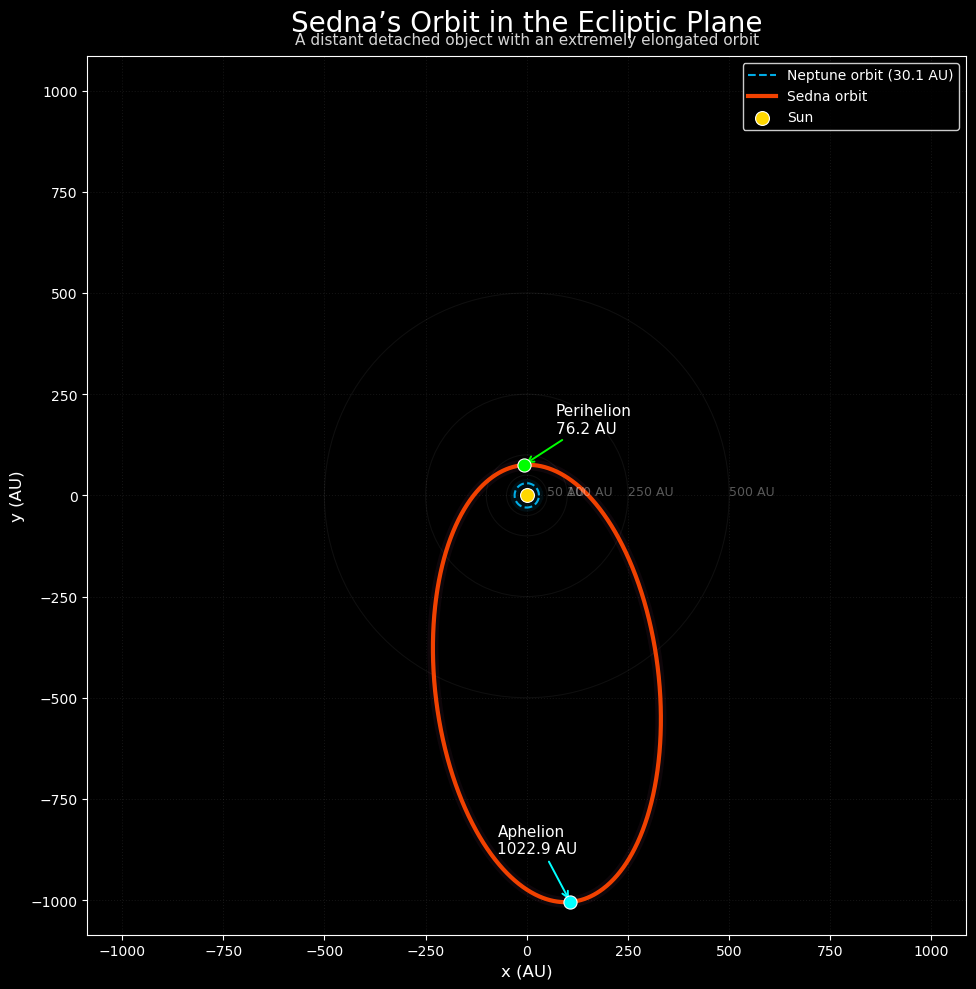

In [6]:
# -----------------------------
# Extract Sedna orbital elements
# -----------------------------
sedna_rows = DDOs[DDOs["Name"] == "Sedna"]

if sedna_rows.empty:
    raise ValueError("Sedna not found in DDOs. Check the 'Name' column values.")

sedna = sedna_rows.iloc[0]

a_au = float(sedna["a"])
e = float(sedna["e"])
i_rad = np.deg2rad(float(sedna["i"]))
omega_rad = np.deg2rad(float(sedna["Peri"]))   # argument of perihelion
Omega_rad = np.deg2rad(float(sedna["Node"]))   # longitude of ascending node

# -----------------------------------
# Rotation matrices for orbital frame
# -----------------------------------
def rotation_matrix_x(angle_rad: float) -> np.ndarray:
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s,  c],
    ])

def rotation_matrix_z(angle_rad: float) -> np.ndarray:
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array([
        [ c, -s, 0.0],
        [ s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ])

# -----------------------------
# Generate Sedna orbit samples
# -----------------------------
true_anomaly = np.linspace(0.0, 2.0 * np.pi, 3000)
r_au = (a_au * (1.0 - e**2)) / (1.0 + e * np.cos(true_anomaly))

x_orb = r_au * np.cos(true_anomaly)
y_orb = r_au * np.sin(true_anomaly)
z_orb = np.zeros_like(x_orb)

rotation = rotation_matrix_z(Omega_rad) @ rotation_matrix_x(i_rad) @ rotation_matrix_z(omega_rad)

positions_orb = np.vstack([x_orb, y_orb, z_orb])
positions_ecl = rotation @ positions_orb

x = positions_ecl[0]
y = positions_ecl[1]

# -----------------------------
# Special orbital points
# -----------------------------
q = a_au * (1 - e)   # perihelion distance
Q = a_au * (1 + e)   # aphelion distance

peri_orb = np.array([[q], [0.0], [0.0]])
aphe_orb = np.array([[-Q], [0.0], [0.0]])

peri_ecl = (rotation @ peri_orb).flatten()
aphe_ecl = (rotation @ aphe_orb).flatten()

# -----------------------------
# Neptune circular orbit
# -----------------------------
neptune_angle = np.linspace(0.0, 2.0 * np.pi, 1000)
neptune_x = NEPTUNE_AVERAGE_DISTANCE * np.cos(neptune_angle)
neptune_y = NEPTUNE_AVERAGE_DISTANCE * np.sin(neptune_angle)

# -----------------------------
# Plot styling
# -----------------------------
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Neptune orbit glow
ax.plot(neptune_x, neptune_y, color="deepskyblue", linewidth=6, alpha=0.08)
ax.plot(neptune_x, neptune_y, color="deepskyblue", linestyle="--", linewidth=1.5, alpha=0.9, label="Neptune orbit (30.1 AU)")

# Sedna orbit glow
ax.plot(x, y, color="hotpink", linewidth=8, alpha=0.06)
ax.plot(x, y, color="orangered", linewidth=3.0, alpha=0.95, label="Sedna orbit")

# Sun
ax.scatter([0.0], [0.0], s=100, color="gold", edgecolor="white", linewidth=0.8, zorder=10, label="Sun")

# Perihelion and aphelion
ax.scatter(peri_ecl[0], peri_ecl[1], s=90, color="lime", edgecolor="white", linewidth=0.8, zorder=11)
ax.scatter(aphe_ecl[0], aphe_ecl[1], s=90, color="cyan", edgecolor="white", linewidth=0.8, zorder=11)

ax.annotate(
    f"Perihelion\n{q:.1f} AU",
    xy=(peri_ecl[0], peri_ecl[1]),
    xytext=(peri_ecl[0] + 80, peri_ecl[1] + 80),
    color="white",
    fontsize=11,
    arrowprops=dict(arrowstyle="->", color="lime", lw=1.4),
)

ax.annotate(
    f"Aphelion\n{Q:.1f} AU",
    xy=(aphe_ecl[0], aphe_ecl[1]),
    xytext=(aphe_ecl[0] - 180, aphe_ecl[1] + 120),
    color="white",
    fontsize=11,
    arrowprops=dict(arrowstyle="->", color="cyan", lw=1.4),
)

# Optional subtle radial guide circles
for radius in [50, 100, 250, 500]:
    circle = plt.Circle((0, 0), radius, color="white", fill=False, alpha=0.06, linewidth=0.8)
    ax.add_patch(circle)
    ax.text(radius, 0, f"{radius} AU", color="white", alpha=0.35, fontsize=9)

# Layout
limit = max(np.max(np.abs(x)), np.max(np.abs(y))) * 1.08
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect("equal", adjustable="box")

ax.set_title("Sedna’s Orbit in the Ecliptic Plane", fontsize=20, pad=18, color="white")
ax.text(
    0.5, 1.01,
    "A distant detached object with an extremely elongated orbit",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color="lightgray"
)

ax.set_xlabel("x (AU)", fontsize=12)
ax.set_ylabel("y (AU)", fontsize=12)
ax.grid(True, color="white", alpha=0.08, linestyle=":")

leg = ax.legend(loc="upper right", frameon=True, facecolor="black", edgecolor="white")
for text in leg.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.show()

# 2D DDO Orbits Around the Sun

Plotting 77 valid DDOs


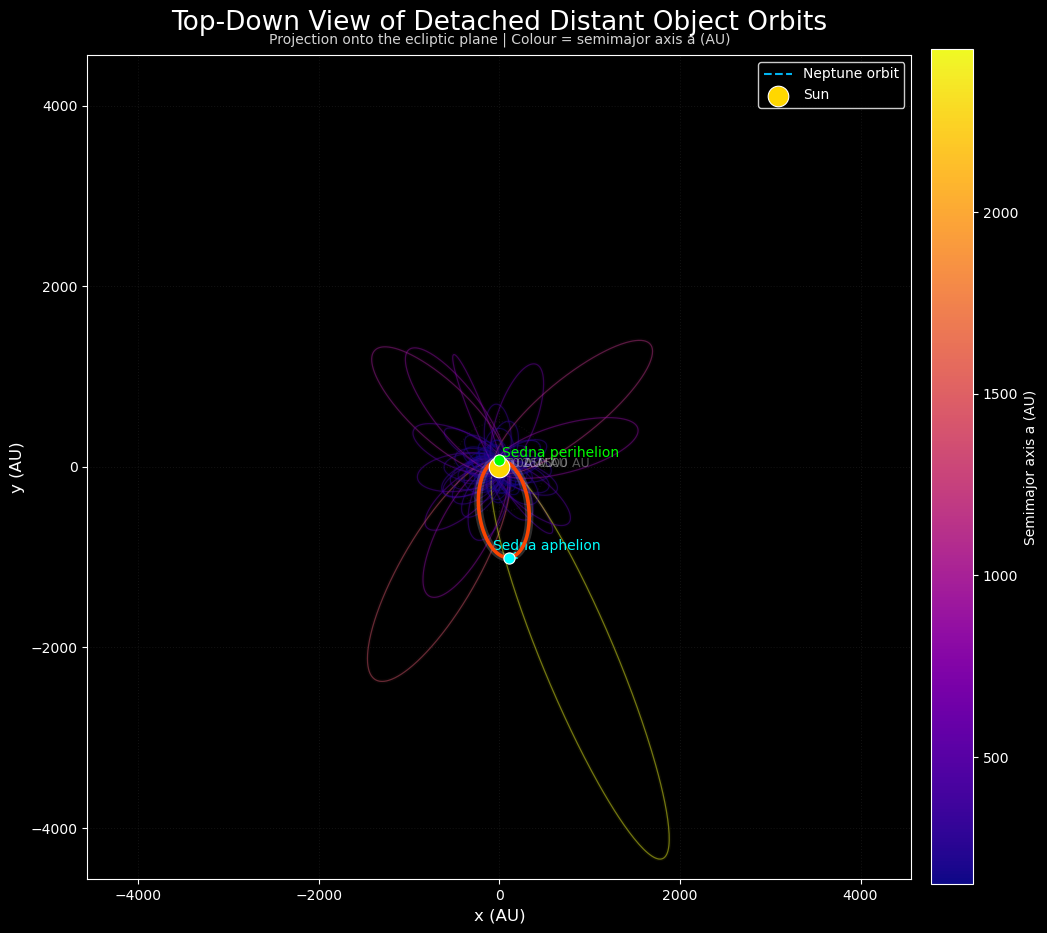

In [7]:
# ============================================================
# Settings
# ============================================================
N_SAMPLES_ORBIT = 2000
HIGHLIGHT_NAME = "Sedna"   # set to None if you do not want a highlight

# ============================================================
# Rotation matrices
# ============================================================
def rotation_matrix_x(angle_rad: float) -> np.ndarray:
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s,  c],
    ])


def rotation_matrix_z(angle_rad: float) -> np.ndarray:
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array([
        [ c, -s, 0.0],
        [ s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ])

# ============================================================
# Compute orbit in ecliptic coordinates
# ============================================================
def compute_orbit_projected_xy(row: pd.Series, n_samples: int = 2000) -> dict:
    a_au = float(row["a"])
    e = float(row["e"])
    i_rad = np.deg2rad(float(row["i"]))
    omega_rad = np.deg2rad(float(row["Peri"]))
    Omega_rad = np.deg2rad(float(row["Node"]))

    true_anomaly = np.linspace(0.0, 2.0 * np.pi, n_samples)
    r_au = (a_au * (1.0 - e**2)) / (1.0 + e * np.cos(true_anomaly))

    x_orb = r_au * np.cos(true_anomaly)
    y_orb = r_au * np.sin(true_anomaly)
    z_orb = np.zeros_like(x_orb)

    positions_orb = np.vstack([x_orb, y_orb, z_orb])

    rotation = (
        rotation_matrix_z(Omega_rad)
        @ rotation_matrix_x(i_rad)
        @ rotation_matrix_z(omega_rad)
    )

    positions_ecl = rotation @ positions_orb

    x = positions_ecl[0]
    y = positions_ecl[1]

    q = a_au * (1.0 - e)
    Q = a_au * (1.0 + e)

    peri_orb = np.array([[q], [0.0], [0.0]])
    aphe_orb = np.array([[-Q], [0.0], [0.0]])

    peri_ecl = (rotation @ peri_orb).flatten()
    aphe_ecl = (rotation @ aphe_orb).flatten()

    return {
        "x": x,
        "y": y,
        "q": q,
        "Q": Q,
        "peri_ecl": peri_ecl,
        "aphe_ecl": aphe_ecl,
    }

# ============================================================
# Clean dataframe
# ============================================================
plot_df = DDOs.copy()

plot_df["display_name"] = plot_df["Name"].fillna(plot_df["Principal_desig"])
plot_df["display_name"] = plot_df["display_name"].astype(str).str.strip()
plot_df["display_name"] = plot_df["display_name"].replace({"": np.nan, "nan": np.nan})

for col in ["a", "e", "i", "Peri", "Node"]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=["a", "e", "i", "Peri", "Node"]).copy()
plot_df = plot_df[plot_df["a"] > 0].copy()
plot_df = plot_df[(plot_df["e"] >= 0) & (plot_df["e"] < 1)].copy()

if len(plot_df) == 0:
    raise ValueError("No valid DDO rows available after cleaning.")

print(f"Plotting {len(plot_df)} valid DDOs")

# ============================================================
# Colour mapping
# ============================================================
a_values = plot_df["a"].to_numpy()
norm = colors.Normalize(vmin=np.min(a_values), vmax=np.max(a_values))
cmap = cm.plasma

# ============================================================
# Set up figure
# ============================================================
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(11, 11))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Neptune orbit
theta = np.linspace(0.0, 2.0 * np.pi, 1000)
neptune_x = NEPTUNE_AVERAGE_DISTANCE * np.cos(theta)
neptune_y = NEPTUNE_AVERAGE_DISTANCE * np.sin(theta)

ax.plot(
    neptune_x,
    neptune_y,
    linestyle="--",
    linewidth=1.5,
    color="deepskyblue",
    alpha=0.95,
    label="Neptune orbit"
)

# Sun
ax.scatter(
    [0.0], [0.0],
    s=220,
    color="gold",
    edgecolor="white",
    linewidth=0.8,
    zorder=20,
    label="Sun"
)

# ============================================================
# Plot all DDO orbits
# ============================================================
max_abs = 0.0

for _, row in plot_df.iterrows():
    orbit = compute_orbit_projected_xy(row, n_samples=N_SAMPLES_ORBIT)

    x = orbit["x"]
    y = orbit["y"]

    color = cmap(norm(float(row["a"])))
    is_highlight = (HIGHLIGHT_NAME is not None) and (row["display_name"] == HIGHLIGHT_NAME)

    # Glow
    ax.plot(
        x, y,
        linewidth=6 if is_highlight else 3,
        color="white" if is_highlight else color,
        alpha=0.18 if is_highlight else 0.05,
        zorder=3 if is_highlight else 1
    )

    # Main orbit
    ax.plot(
        x, y,
        linewidth=2.6 if is_highlight else 0.9,
        color="orangered" if is_highlight else color,
        alpha=0.98 if is_highlight else 0.45,
        zorder=4 if is_highlight else 2
    )

    if is_highlight:
        peri = orbit["peri_ecl"]
        aphe = orbit["aphe_ecl"]

        ax.scatter(
            [peri[0]], [peri[1]],
            s=65, color="lime", edgecolor="white", linewidth=0.8, zorder=30
        )
        ax.scatter(
            [aphe[0]], [aphe[1]],
            s=65, color="cyan", edgecolor="white", linewidth=0.8, zorder=30
        )

        ax.annotate(
            f"{row['display_name']} perihelion",
            xy=(peri[0], peri[1]),
            xytext=(peri[0] + 40, peri[1] + 40),
            color="lime",
            fontsize=10,
            arrowprops=dict(arrowstyle="->", color="lime", lw=1.2)
        )

        ax.annotate(
            f"{row['display_name']} aphelion",
            xy=(aphe[0], aphe[1]),
            xytext=(aphe[0] - 180, aphe[1] + 80),
            color="cyan",
            fontsize=10,
            arrowprops=dict(arrowstyle="->", color="cyan", lw=1.2)
        )

    local_max = np.max(np.abs(np.concatenate([x, y])))
    max_abs = max(max_abs, local_max)

# ============================================================
# Optional radial guide rings
# ============================================================
for radius in [50, 100, 250, 500]:
    circle = plt.Circle(
        (0, 0),
        radius,
        color="white",
        fill=False,
        alpha=0.06,
        linewidth=0.8,
        linestyle=":"
    )
    ax.add_patch(circle)
    ax.text(radius, 0, f"{radius} AU", color="white", alpha=0.35, fontsize=9)

# ============================================================
# Final styling
# ============================================================
limit = max_abs * 1.05
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (AU)", fontsize=12)
ax.set_ylabel("y (AU)", fontsize=12)

ax.set_title("Top-Down View of Detached Distant Object Orbits", fontsize=19, pad=18)
ax.text(
    0.5, 1.01,
    "Projection onto the ecliptic plane | Colour = semimajor axis a (AU)",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="lightgray"
)

ax.grid(True, color="white", alpha=0.07, linestyle=":")
leg = ax.legend(loc="upper right", frameon=True, facecolor="black", edgecolor="white")
for text in leg.get_texts():
    text.set_color("white")

# Colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.78)
cbar.set_label("Semimajor axis a (AU)")

plt.tight_layout()
plt.show()

# 3D DDO Orbits Around the Sun

Usable DDO rows: 77
Plotting 77 objects
['2001 FP185', '2000 CR105', '2010 VZ98', 'Alicanto', '2013 UT15', '2003 HB57', '2015 SO20', '2007 TG422', '2007 VJ305', 'Leleakuhonua', '2014 OS394', '2016 QU89', '2013 FL28', '2013 RA109', '2013 SL102', '2015 BP519', '2016 QV89', '2002 GB32', '2003 SS422', '2005 RH52', '2010 GB174', '2012 VP113', '2013 FS28', '2013 FT28', '2013 RF98', '2013 RC156', '2013 SY99', '2013 UH15', '2014 FE72', '2014 SR349', '2014 SX403', '2014 TS115', '2014 TU115', '2014 WB556', '2015 DY248', '2015 DM319', '2015 FA400', '2015 FQ561', '2015 GT50', '2015 JB13', '2015 KG163', '2015 KH163', '2015 OC193', '2015 OB203', '2015 RX245', '2015 RY245', '2015 UN105', '2015 VQ207', '2016 EC366', '2016 GA277', '2016 SG58', '2016 SA59', '2016 SD106', '2016 TP120', '2017 CL54', '2017 DV177', '2017 OF201', '2018 AD39', '2018 VM35', '2019 EU5', '2019 EE6', '2019 GT195', '2019 GE199', '2020 KW54', '2020 MQ53', '2021 DK18', '2021 LP43', '2021 RR205', '2023 KQ14', '2024 FX26', '2025 LJ2',

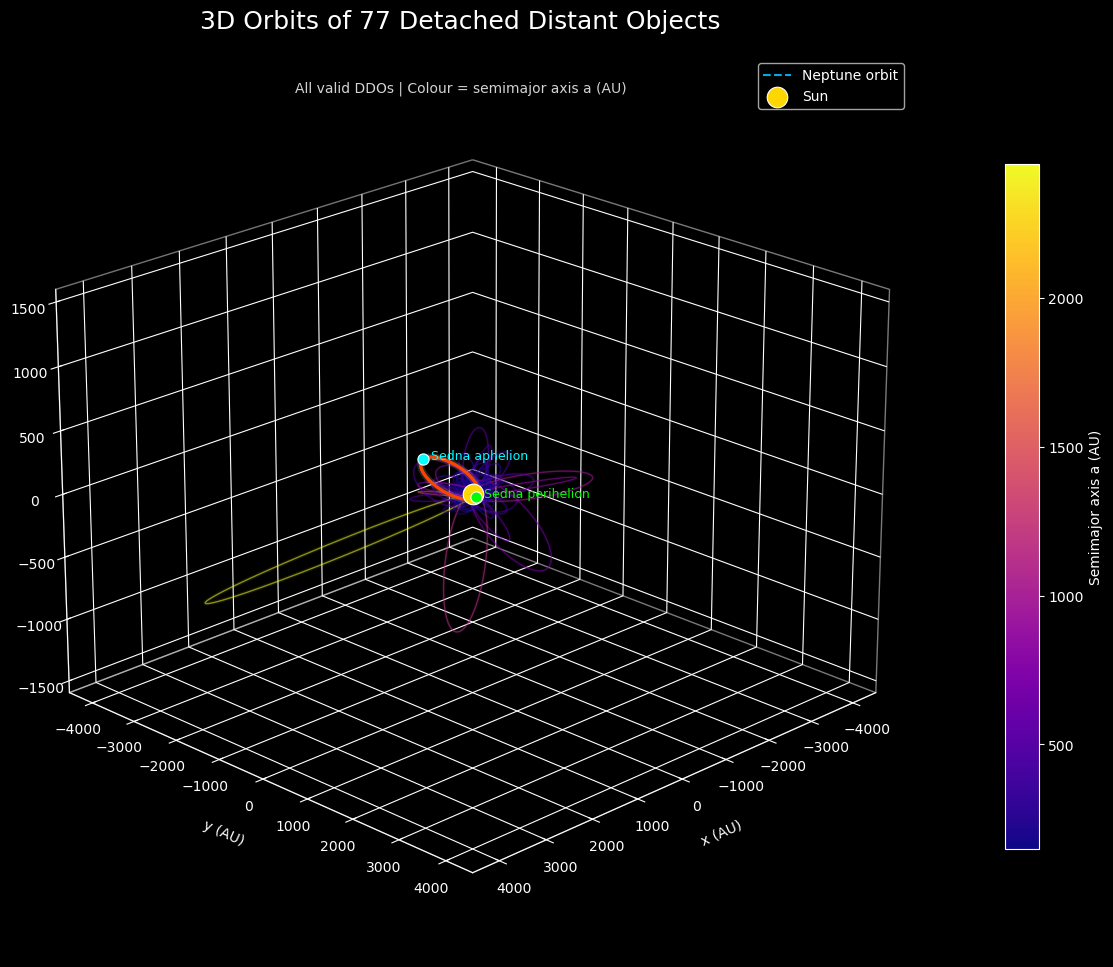

In [8]:
# %matplotlib widget
# ============================================================
# Settings
# ============================================================
N_SAMPLES_ORBIT = 1200     # points per orbit
HIGHLIGHT_NAME = "Sedna"   # set to None if you do not want a highlighted object

# ============================================================
# Rotation matrices
# ============================================================
def rotation_matrix_x(angle_rad: float) -> np.ndarray:
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s,  c],
    ])


def rotation_matrix_z(angle_rad: float) -> np.ndarray:
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array([
        [ c, -s, 0.0],
        [ s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ])


# ============================================================
# Orbit computation
# ============================================================
def compute_orbit_3d(row: pd.Series, n_samples: int = 1200) -> dict:
    a_au = float(row["a"])
    e = float(row["e"])
    i_rad = np.deg2rad(float(row["i"]))
    omega_rad = np.deg2rad(float(row["Peri"]))   # argument of perihelion
    Omega_rad = np.deg2rad(float(row["Node"]))   # longitude of ascending node

    true_anomaly = np.linspace(0.0, 2.0 * np.pi, n_samples)
    r_au = (a_au * (1.0 - e**2)) / (1.0 + e * np.cos(true_anomaly))

    x_orb = r_au * np.cos(true_anomaly)
    y_orb = r_au * np.sin(true_anomaly)
    z_orb = np.zeros_like(x_orb)

    positions_orb = np.vstack([x_orb, y_orb, z_orb])

    rotation = (
        rotation_matrix_z(Omega_rad)
        @ rotation_matrix_x(i_rad)
        @ rotation_matrix_z(omega_rad)
    )

    positions_ecl = rotation @ positions_orb

    x = positions_ecl[0]
    y = positions_ecl[1]
    z = positions_ecl[2]

    q = a_au * (1.0 - e)
    Q = a_au * (1.0 + e)

    peri_orb = np.array([[q], [0.0], [0.0]])
    aphe_orb = np.array([[-Q], [0.0], [0.0]])

    peri_ecl = (rotation @ peri_orb).flatten()
    aphe_ecl = (rotation @ aphe_orb).flatten()

    return {
        "x": x,
        "y": y,
        "z": z,
        "q": q,
        "Q": Q,
        "peri_ecl": peri_ecl,
        "aphe_ecl": aphe_ecl,
    }


# ============================================================
# Clean dataframe
# ============================================================
plot_df = DDOs.copy()

# Use Name if available, otherwise Principal_desig
plot_df["display_name"] = plot_df["Name"].fillna(plot_df["Principal_desig"])

# Clean up blank strings
plot_df["display_name"] = plot_df["display_name"].astype(str).str.strip()
plot_df["display_name"] = plot_df["display_name"].replace({"": np.nan, "nan": np.nan})

# Convert orbital columns to numeric
for col in ["a", "e", "i", "Peri", "Node"]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# Keep only valid orbital rows
plot_df = plot_df.dropna(subset=["a", "e", "i", "Peri", "Node"]).copy()
plot_df = plot_df[plot_df["a"] > 0].copy()
plot_df = plot_df[(plot_df["e"] >= 0) & (plot_df["e"] < 1)].copy()

if len(plot_df) == 0:
    raise ValueError("No valid DDO rows available after cleaning.")

print(f"Usable DDO rows: {len(plot_df)}")

# ============================================================
# Plot all valid objects
# ============================================================
sampled_df = plot_df.copy()

# If highlight object exists, move it to the end so it plots on top
if HIGHLIGHT_NAME is not None:
    highlight_matches = sampled_df[sampled_df["display_name"] == HIGHLIGHT_NAME]

    if not highlight_matches.empty:
        sampled_df = sampled_df[sampled_df["display_name"] != HIGHLIGHT_NAME]
        sampled_df = pd.concat([sampled_df, highlight_matches], ignore_index=True)

print(f"Plotting {len(sampled_df)} objects")
print(sampled_df["display_name"].tolist())

# ============================================================
# Colour mapping by semimajor axis
# ============================================================
a_values = sampled_df["a"].to_numpy()
norm = colors.Normalize(vmin=np.min(a_values), vmax=np.max(a_values))
cmap = cm.plasma

# ============================================================
# Figure setup
# ============================================================
plt.style.use("dark_background")
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Ecliptic plane
plane_extent = 80
plane_grid = np.linspace(-plane_extent, plane_extent, 2)
plane_X, plane_Y = np.meshgrid(plane_grid, plane_grid)
plane_Z = np.zeros_like(plane_X)

ax.plot_surface(
    plane_X,
    plane_Y,
    plane_Z,
    alpha=0.06,
    color="deepskyblue",
    edgecolor="none"
)

# Neptune orbit
theta = np.linspace(0.0, 2.0 * np.pi, 1000)
neptune_x = NEPTUNE_AVERAGE_DISTANCE * np.cos(theta)
neptune_y = NEPTUNE_AVERAGE_DISTANCE * np.sin(theta)
neptune_z = np.zeros_like(theta)

ax.plot(
    neptune_x,
    neptune_y,
    neptune_z,
    linestyle="--",
    linewidth=1.5,
    color="deepskyblue",
    alpha=0.9,
    label="Neptune orbit"
)

# Sun
ax.scatter(
    [0.0], [0.0], [0.0],
    s=220,
    color="gold",
    edgecolor="white",
    linewidth=0.8,
    label="Sun",
    zorder=10
)

# ============================================================
# Plot each orbit
# ============================================================
max_abs = 0.0

for _, row in sampled_df.iterrows():
    orbit = compute_orbit_3d(row, n_samples=N_SAMPLES_ORBIT)

    x = orbit["x"]
    y = orbit["y"]
    z = orbit["z"]

    color = cmap(norm(float(row["a"])))
    is_highlight = (HIGHLIGHT_NAME is not None) and (row["display_name"] == HIGHLIGHT_NAME)

    # Glow pass
    ax.plot(
        x, y, z,
        linewidth=5 if is_highlight else 3,
        color="white" if is_highlight else color,
        alpha=0.15 if is_highlight else 0.07
    )

    # Main pass
    ax.plot(
        x, y, z,
        linewidth=2.4 if is_highlight else 1.0,
        color="orangered" if is_highlight else color,
        alpha=0.98 if is_highlight else 0.55
    )

    # Label highlighted object
    if is_highlight:
        peri = orbit["peri_ecl"]
        aphe = orbit["aphe_ecl"]

        ax.scatter(
            [peri[0]], [peri[1]], [peri[2]],
            s=65, color="lime", edgecolor="white", linewidth=0.8
        )
        ax.scatter(
            [aphe[0]], [aphe[1]], [aphe[2]],
            s=65, color="cyan", edgecolor="white", linewidth=0.8
        )

        ax.text(
            peri[0], peri[1], peri[2],
            f"  {row['display_name']} perihelion",
            color="lime",
            fontsize=9
        )
        ax.text(
            aphe[0], aphe[1], aphe[2],
            f"  {row['display_name']} aphelion",
            color="cyan",
            fontsize=9
        )

    local_max = np.max(np.abs(np.concatenate([x, y, z])))
    max_abs = max(max_abs, local_max)

# ============================================================
# Axes setup
# ============================================================
limit = max_abs * 1.05
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit * 0.35, limit * 0.35)

ax.set_xlabel("x (AU)", labelpad=10)
ax.set_ylabel("y (AU)", labelpad=10)
ax.set_zlabel("z (AU)", labelpad=10)

ax.set_title(
    f"3D Orbits of {len(sampled_df)} Detached Distant Objects",
    fontsize=18,
    pad=20
)

ax.text2D(
    0.5, 0.96,
    "All valid DDOs | Colour = semimajor axis a (AU)",
    transform=ax.transAxes,
    ha="center",
    color="lightgray",
    fontsize=10
)

# Cleaner panes
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, alpha=0.12)

# Nice viewing angle
ax.view_init(elev=22, azim=45)

# Colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.08, shrink=0.72)
cbar.set_label("Semimajor axis a (AU)")

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Statistical DDO Clustering Analysis

In [9]:
%matplotlib inline

# ============================================================
# Rotation matrices
# ============================================================
def rotation_matrix_x(angle_rad: float) -> np.ndarray:
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s,  c],
    ])


def rotation_matrix_z(angle_rad: float) -> np.ndarray:
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array([
        [ c, -s, 0.0],
        [ s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ])


# ============================================================
# Clean dataframe and add display_name
# ============================================================
def prepare_ddo_dataframe(ddo_df: pd.DataFrame) -> pd.DataFrame:
    plot_df = ddo_df.copy()

    plot_df["display_name"] = plot_df["Name"].fillna(plot_df["Principal_desig"])
    plot_df["display_name"] = plot_df["display_name"].astype(str).str.strip()
    plot_df["display_name"] = plot_df["display_name"].replace({"": np.nan, "nan": np.nan})

    for col in ["a", "e", "i", "Peri", "Node"]:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    plot_df = plot_df.dropna(subset=["a", "e", "i", "Peri", "Node"]).copy()
    plot_df = plot_df[plot_df["a"] > 0].copy()
    plot_df = plot_df[(plot_df["e"] >= 0) & (plot_df["e"] < 1)].copy()

    return plot_df


# ============================================================
# Compute angular diagnostics
# ============================================================
def compute_diagnostics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in df.iterrows():
        a_au = float(row["a"])
        e = float(row["e"])
        i_deg = float(row["i"])
        omega_deg = float(row["Peri"])   # argument of perihelion
        Omega_deg = float(row["Node"])   # longitude of ascending node

        i_rad = np.deg2rad(i_deg)
        omega_rad = np.deg2rad(omega_deg)
        Omega_rad = np.deg2rad(Omega_deg)

        rotation = (
            rotation_matrix_z(Omega_rad)
            @ rotation_matrix_x(i_rad)
            @ rotation_matrix_z(omega_rad)
        )

        q = a_au * (1.0 - e)
        Q = a_au * (1.0 + e)

        peri_orb = np.array([[q], [0.0], [0.0]])
        peri_ecl = (rotation @ peri_orb).flatten()

        perihelion_direction_deg = np.degrees(np.arctan2(peri_ecl[1], peri_ecl[0])) % 360.0
        major_axis_angle_deg = perihelion_direction_deg % 180.0
        longitude_of_perihelion_deg = (Omega_deg + omega_deg) % 360.0

        # Orbital pole direction
        nx = np.sin(i_rad) * np.sin(Omega_rad)
        ny = -np.sin(i_rad) * np.cos(Omega_rad)
        nz = np.cos(i_rad)

        pole_longitude_deg = np.degrees(np.arctan2(ny, nx)) % 360.0
        pole_latitude_deg = np.degrees(np.arcsin(nz))

        rows.append({
            "display_name": row["display_name"],
            "a": a_au,
            "e": e,
            "i": i_deg,
            "q": q,
            "Q": Q,
            "perihelion_direction_deg": perihelion_direction_deg,
            "major_axis_angle_deg": major_axis_angle_deg,
            "longitude_of_perihelion_deg": longitude_of_perihelion_deg,
            "pole_longitude_deg": pole_longitude_deg,
            "pole_latitude_deg": pole_latitude_deg,
        })

    return pd.DataFrame(rows)


# ============================================================
# Monte Carlo uniformity test
# ============================================================
def monte_carlo_uniformity_test(
    angles_deg: np.ndarray,
    angle_max: float,
    n_bins: int,
    n_sim: int = 10000,
    random_seed: int = 42,
) -> dict:
    """
    Test whether the angular distribution looks more clustered than a
    uniform distribution by comparing the largest histogram bin count.

    Parameters
    ----------
    angles_deg : np.ndarray
        Observed angles in degrees.
    angle_max : float
        180 for major-axis angles, 360 for directed angles.
    n_bins : int
        Number of histogram bins.
    n_sim : int
        Number of Monte Carlo simulations.
    random_seed : int
        Random seed for reproducibility.

    Returns
    -------
    dict
        Contains observed counts, simulated max counts, and p-value.
    """
    angles_deg = np.asarray(angles_deg, dtype=float)
    n = len(angles_deg)

    if n == 0:
        raise ValueError("No angles provided to Monte Carlo test.")

    bins = np.linspace(0.0, angle_max, n_bins + 1)
    observed_counts, _ = np.histogram(angles_deg, bins=bins)
    observed_max_bin = observed_counts.max()

    rng = np.random.default_rng(random_seed)
    sim_max_bins = np.empty(n_sim, dtype=int)

    for k in range(n_sim):
        sim_angles = rng.uniform(0.0, angle_max, size=n)
        sim_counts, _ = np.histogram(sim_angles, bins=bins)
        sim_max_bins[k] = sim_counts.max()

    p_value = np.mean(sim_max_bins >= observed_max_bin)

    return {
        "n": n,
        "bins": bins,
        "observed_counts": observed_counts,
        "observed_max_bin": observed_max_bin,
        "sim_max_bins": sim_max_bins,
        "p_value": p_value,
        "n_bins": n_bins,
        "angle_max": angle_max,
    }


# ============================================================
# Simple text interpretation helper
# ============================================================
def interpret_p_value(p_value: float) -> str:
    if p_value < 0.01:
        return "strong evidence against a uniform angular distribution"
    elif p_value < 0.05:
        return "moderate evidence against a uniform angular distribution"
    elif p_value < 0.10:
        return "weak evidence against a uniform angular distribution"
    else:
        return "little evidence against a uniform angular distribution"


# ============================================================
# Main diagnostic function
# ============================================================
def analyse_ddo_subset(
    df: pd.DataFrame,
    subset_name: str = "Subset",
    highlight_name: str = "Sedna",
    mc_bins_major: int = 12,
    mc_bins_long_peri: int = 12,
    n_sim: int = 10000,
    random_seed: int = 42,
    show_tables: bool = True,
) -> pd.DataFrame:
    diagnostics_df = compute_diagnostics(df)

    if len(diagnostics_df) == 0:
        raise ValueError(f"No valid objects in subset '{subset_name}'.")

    # --------------------------------------------------------
    # Monte Carlo tests
    # --------------------------------------------------------
    mc_major = monte_carlo_uniformity_test(
        angles_deg=diagnostics_df["major_axis_angle_deg"].to_numpy(),
        angle_max=180.0,
        n_bins=mc_bins_major,
        n_sim=n_sim,
        random_seed=random_seed,
    )

    mc_long_peri = monte_carlo_uniformity_test(
        angles_deg=diagnostics_df["longitude_of_perihelion_deg"].to_numpy(),
        angle_max=360.0,
        n_bins=mc_bins_long_peri,
        n_sim=n_sim,
        random_seed=random_seed,
    )

    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------
    print("=" * 80)
    print(f"Angular diagnostics for: {subset_name}")
    print("=" * 80)
    print(f"Number of objects: {len(diagnostics_df)}")
    print()

    print("Monte Carlo test: Projected major-axis angle")
    print(f"  Observed largest bin count : {mc_major['observed_max_bin']}")
    print(f"  Monte Carlo p-value        : {mc_major['p_value']:.4f}")
    print(f"  Interpretation             : {interpret_p_value(mc_major['p_value'])}")
    print()

    print("Monte Carlo test: Longitude of perihelion")
    print(f"  Observed largest bin count : {mc_long_peri['observed_max_bin']}")
    print(f"  Monte Carlo p-value        : {mc_long_peri['p_value']:.4f}")
    print(f"  Interpretation             : {interpret_p_value(mc_long_peri['p_value'])}")
    print()

    if show_tables:
        print("Top 10 by semimajor axis:")
        display(
            diagnostics_df.sort_values("a", ascending=False)[
                [
                    "display_name", "a", "e", "i", "q", "Q",
                    "major_axis_angle_deg",
                    "longitude_of_perihelion_deg",
                    "pole_longitude_deg", "pole_latitude_deg"
                ]
            ].head(10)
        )

    # --------------------------------------------------------
    # Three-panel figure
    # --------------------------------------------------------
    plt.style.use("dark_background")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))

    # Panel 1: major-axis angle
    axes[0].hist(
        diagnostics_df["major_axis_angle_deg"],
        bins=np.linspace(0, 180, 19),
        edgecolor="white",
        alpha=0.85
    )
    axes[0].set_title("Projected Major-Axis Angle")
    axes[0].set_xlabel("Angle in ecliptic plane (deg)")
    axes[0].set_ylabel("Count")
    axes[0].set_xlim(0, 180)
    axes[0].set_xticks(np.arange(0, 181, 30))
    axes[0].grid(True, alpha=0.2, linestyle=":")

    # Panel 2: longitude of perihelion
    axes[1].hist(
        diagnostics_df["longitude_of_perihelion_deg"],
        bins=np.linspace(0, 360, 25),
        edgecolor="white",
        alpha=0.85
    )
    axes[1].set_title("Longitude of Perihelion")
    axes[1].set_xlabel(r"$\varpi = \Omega + \omega$ (deg)")
    axes[1].set_ylabel("Count")
    axes[1].set_xlim(0, 360)
    axes[1].set_xticks(np.arange(0, 361, 60))
    axes[1].grid(True, alpha=0.2, linestyle=":")

    # Panel 3: orbital poles
    axes[2].scatter(
        diagnostics_df["pole_longitude_deg"],
        diagnostics_df["pole_latitude_deg"],
        s=45,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5
    )

    if highlight_name is not None:
        match = diagnostics_df[diagnostics_df["display_name"] == highlight_name]
        if not match.empty:
            row = match.iloc[0]
            axes[2].scatter(
                [row["pole_longitude_deg"]],
                [row["pole_latitude_deg"]],
                s=120,
                color="orangered",
                edgecolor="white",
                linewidth=1.0,
                zorder=10
            )
            axes[2].annotate(
                highlight_name,
                xy=(row["pole_longitude_deg"], row["pole_latitude_deg"]),
                xytext=(row["pole_longitude_deg"] + 10, row["pole_latitude_deg"] - 5),
                color="white",
                fontsize=10,
                arrowprops=dict(arrowstyle="->", lw=1.0, color="white")
            )

    axes[2].set_title("Orbital Pole Directions")
    axes[2].set_xlabel("Pole longitude (deg)")
    axes[2].set_ylabel("Pole latitude (deg)")
    axes[2].set_xlim(0, 360)
    axes[2].set_ylim(-90, 90)
    axes[2].set_xticks(np.arange(0, 361, 60))
    axes[2].set_yticks(np.arange(-90, 91, 30))
    axes[2].grid(True, alpha=0.2, linestyle=":")

    fig.suptitle(f"Detached Distant Object Angular Diagnostics: {subset_name}", fontsize=18, y=1.03)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Monte Carlo reference plots
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].hist(
        mc_major["sim_max_bins"],
        bins=np.arange(mc_major["sim_max_bins"].min(), mc_major["sim_max_bins"].max() + 2) - 0.5,
        edgecolor="white",
        alpha=0.85
    )
    axes[0].axvline(mc_major["observed_max_bin"], color="red", linestyle="--", linewidth=2)
    axes[0].set_title("MC Test: Major-Axis Angle")
    axes[0].set_xlabel("Largest bin count under uniform angles")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, alpha=0.2, linestyle=":")

    axes[1].hist(
        mc_long_peri["sim_max_bins"],
        bins=np.arange(mc_long_peri["sim_max_bins"].min(), mc_long_peri["sim_max_bins"].max() + 2) - 0.5,
        edgecolor="white",
        alpha=0.85
    )
    axes[1].axvline(mc_long_peri["observed_max_bin"], color="red", linestyle="--", linewidth=2)
    axes[1].set_title("MC Test: Longitude of Perihelion")
    axes[1].set_xlabel("Largest bin count under uniform angles")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, alpha=0.2, linestyle=":")

    plt.tight_layout()
    plt.show()

    return diagnostics_df

Prepare the DDO dataframe.

In [10]:
plot_df = prepare_ddo_dataframe(DDOs)
print(len(plot_df))

77


Angular diagnostics for: All valid DDOs
Number of objects: 77

Monte Carlo test: Projected major-axis angle
  Observed largest bin count : 12
  Monte Carlo p-value        : 0.2851
  Interpretation             : little evidence against a uniform angular distribution

Monte Carlo test: Longitude of perihelion
  Observed largest bin count : 12
  Monte Carlo p-value        : 0.2851
  Interpretation             : little evidence against a uniform angular distribution

Top 10 by semimajor axis:


,display_name,a,e,i,q,Q,major_axis_angle_deg,longitude_of_perihelion_deg,pole_longitude_deg,pole_latitude_deg
29,2014 FE72,2447.679597,0.985290,20.61112,36.005367,4859.353827,112.564182,110.66952,246.76872,69.38888
10,Leleakuhonua,1418.608757,0.954383,11.67835,64.712534,2772.504980,59.773242,59.27186,211.12607,78.32165
60,2019 EU5,1150.249432,0.959079,18.16063,47.069357,2253.429507,38.952878,218.03762,19.14090,71.83937
68,2021 RR205,973.783531,0.942859,7.64886,55.642867,1891.924194,137.006674,317.22220,18.45041,82.35114
57,2017 OF201,846.412762,0.946592,16.21706,45.205044,1647.620481,127.514563,306.71824,238.72164,73.78294
27,2013 SY99,839.991262,0.940576,4.22267,49.915977,1630.066548,61.660199,61.73040,299.51857,85.77733
66,2021 DK18,837.282260,0.946749,15.39748,44.586285,1629.978235,15.646830,196.64411,232.27286,74.60252
65,2020 MQ53,728.532274,0.923679,73.51501,55.602312,1401.462236,112.545119,305.52670,197.16439,16.48499
41,2015 KG163,628.535978,0.935588,14.00966,40.485071,1216.586884,70.343553,251.11536,129.15162,75.99034
8,2007 TG422,567.924050,0.937288,18.56583,35.615653,1100.232448,39.708199,38.88184,22.95883,71.43417


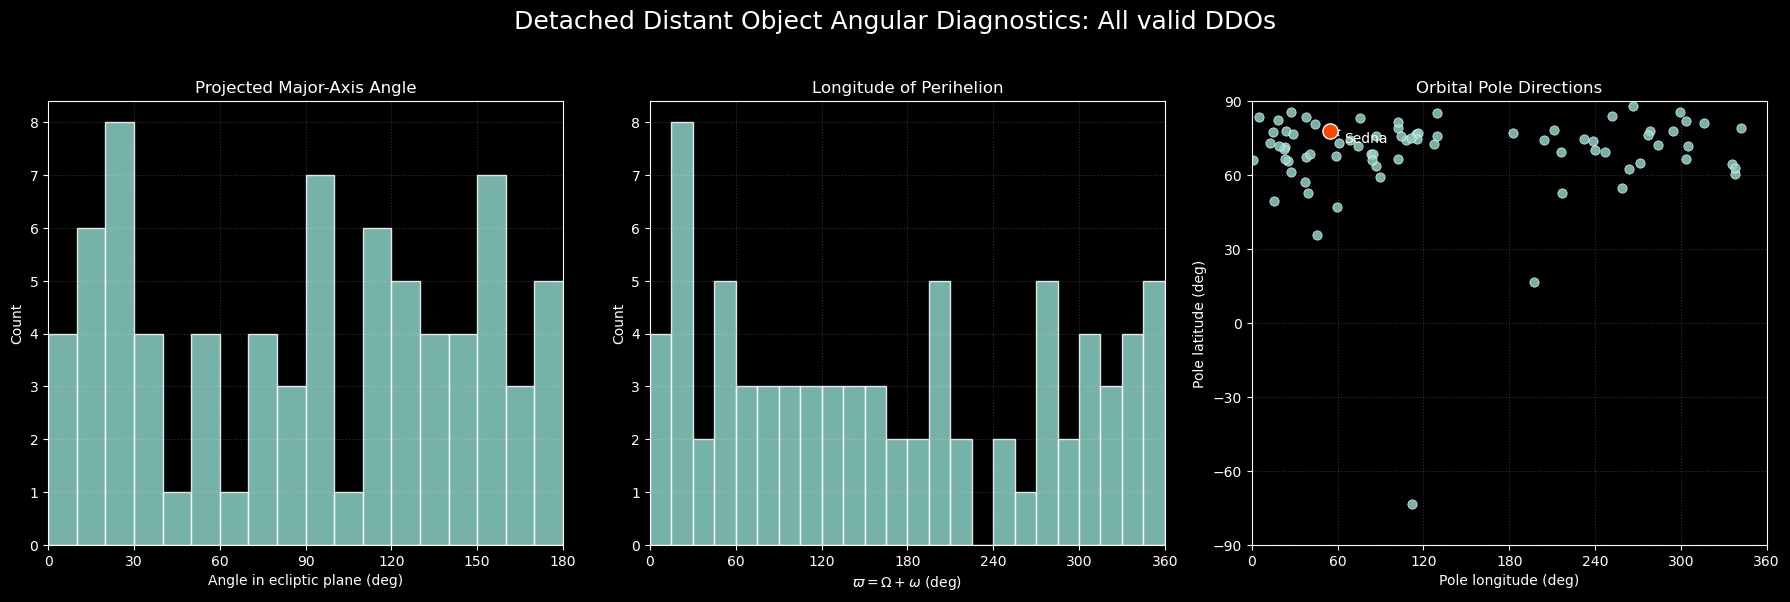

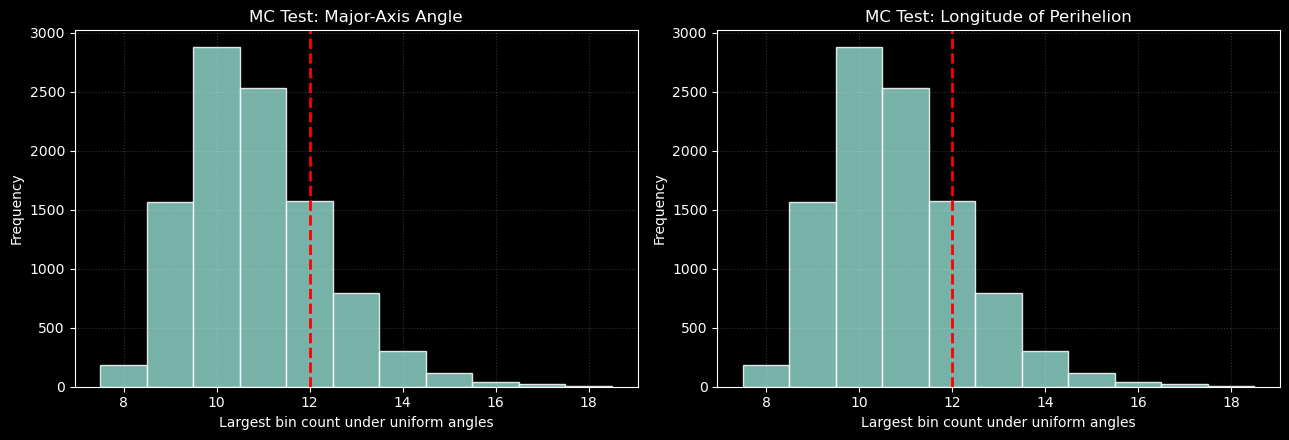

In [11]:
diagnostics_all = analyse_ddo_subset(
    df=plot_df,
    subset_name="All valid DDOs",
    highlight_name="Sedna",
    n_sim=10000,
)

Angular diagnostics for: a > 250 AU
Number of objects: 37

Monte Carlo test: Projected major-axis angle
  Observed largest bin count : 7
  Monte Carlo p-value        : 0.3475
  Interpretation             : little evidence against a uniform angular distribution

Monte Carlo test: Longitude of perihelion
  Observed largest bin count : 7
  Monte Carlo p-value        : 0.3475
  Interpretation             : little evidence against a uniform angular distribution

Top 10 by semimajor axis:


,display_name,a,e,i,q,Q,major_axis_angle_deg,longitude_of_perihelion_deg,pole_longitude_deg,pole_latitude_deg
13,2014 FE72,2447.679597,0.985290,20.61112,36.005367,4859.353827,112.564182,110.66952,246.76872,69.38888
3,Leleakuhonua,1418.608757,0.954383,11.67835,64.712534,2772.504980,59.773242,59.27186,211.12607,78.32165
30,2019 EU5,1150.249432,0.959079,18.16063,47.069357,2253.429507,38.952878,218.03762,19.14090,71.83937
33,2021 RR205,973.783531,0.942859,7.64886,55.642867,1891.924194,137.006674,317.22220,18.45041,82.35114
28,2017 OF201,846.412762,0.946592,16.21706,45.205044,1647.620481,127.514563,306.71824,238.72164,73.78294
12,2013 SY99,839.991262,0.940576,4.22267,49.915977,1630.066548,61.660199,61.73040,299.51857,85.77733
32,2021 DK18,837.282260,0.946749,15.39748,44.586285,1629.978235,15.646830,196.64411,232.27286,74.60252
31,2020 MQ53,728.532274,0.923679,73.51501,55.602312,1401.462236,112.545119,305.52670,197.16439,16.48499
24,2015 KG163,628.535978,0.935588,14.00966,40.485071,1216.586884,70.343553,251.11536,129.15162,75.99034
2,2007 TG422,567.924050,0.937288,18.56583,35.615653,1100.232448,39.708199,38.88184,22.95883,71.43417


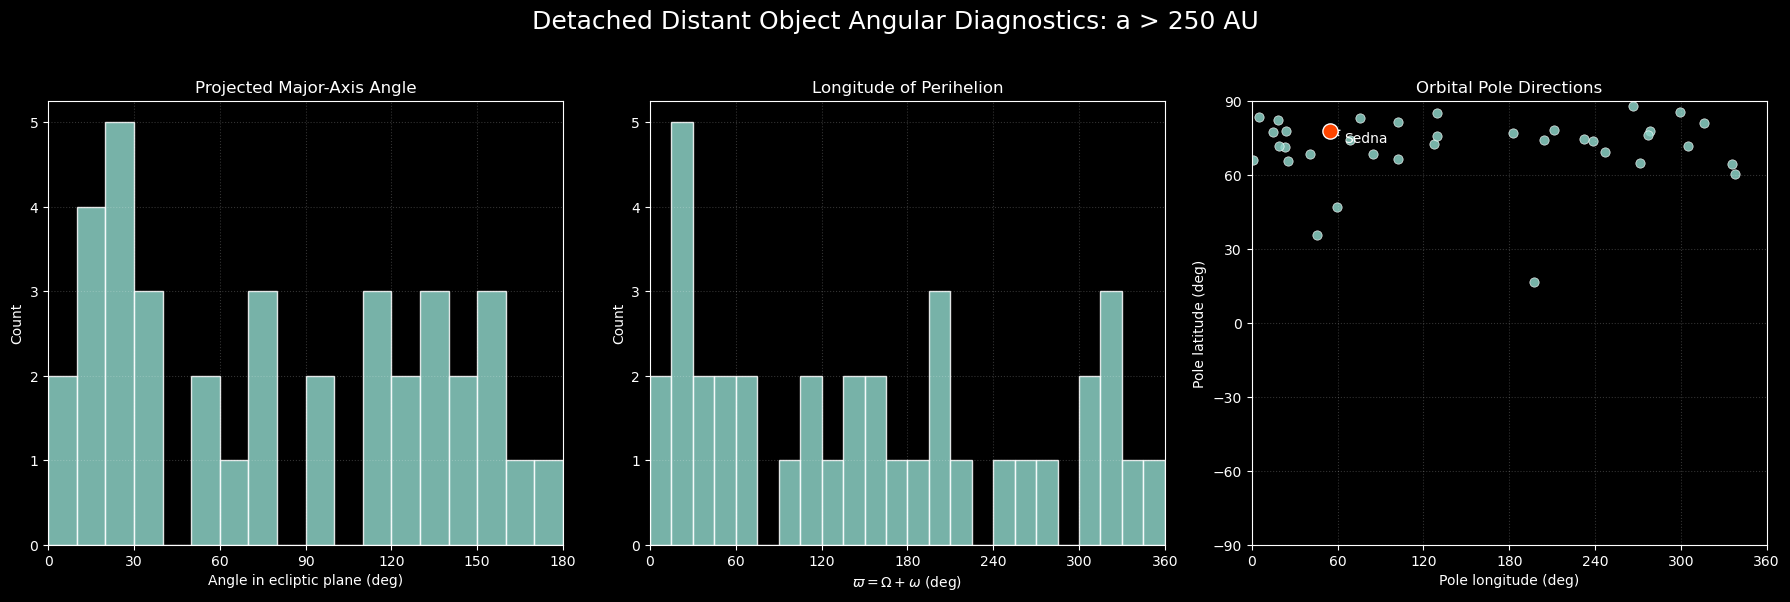

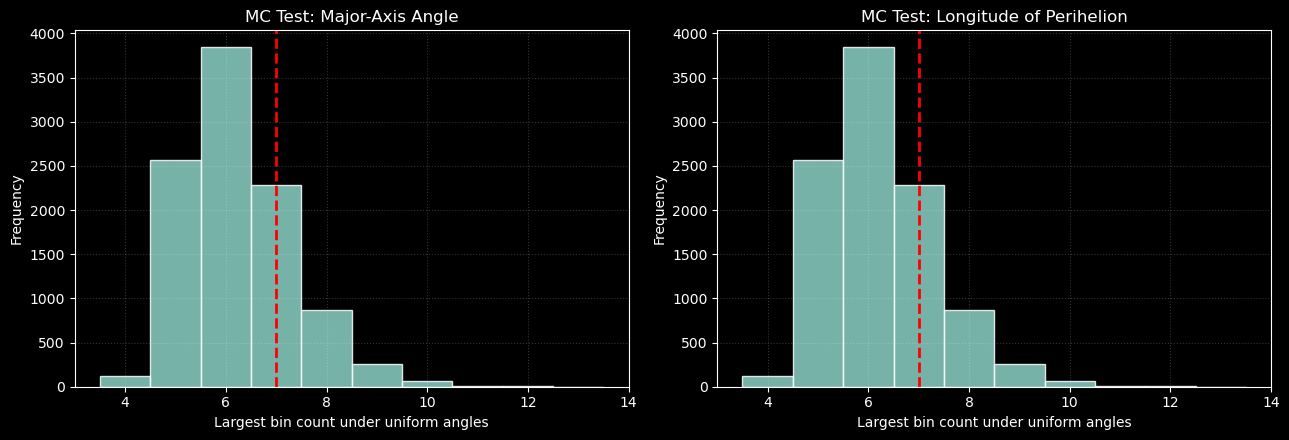

In [12]:
subset_a250 = plot_df[plot_df["a"] > 250].copy()

diagnostics_a250 = analyse_ddo_subset(
    df=subset_a250,
    subset_name="a > 250 AU",
    highlight_name="Sedna",
    n_sim=10000,
)

Angular diagnostics for: a > 250 AU and q > 40 AU
Number of objects: 21

Monte Carlo test: Projected major-axis angle
  Observed largest bin count : 4
  Monte Carlo p-value        : 0.7807
  Interpretation             : little evidence against a uniform angular distribution

Monte Carlo test: Longitude of perihelion
  Observed largest bin count : 4
  Monte Carlo p-value        : 0.7807
  Interpretation             : little evidence against a uniform angular distribution

Top 10 by semimajor axis:


,display_name,a,e,i,q,Q,major_axis_angle_deg,longitude_of_perihelion_deg,pole_longitude_deg,pole_latitude_deg
2,Leleakuhonua,1418.608757,0.954383,11.67835,64.712534,2772.504980,59.773242,59.27186,211.12607,78.32165
15,2019 EU5,1150.249432,0.959079,18.16063,47.069357,2253.429507,38.952878,218.03762,19.14090,71.83937
18,2021 RR205,973.783531,0.942859,7.64886,55.642867,1891.924194,137.006674,317.22220,18.45041,82.35114
13,2017 OF201,846.412762,0.946592,16.21706,45.205044,1647.620481,127.514563,306.71824,238.72164,73.78294
7,2013 SY99,839.991262,0.940576,4.22267,49.915977,1630.066548,61.660199,61.73040,299.51857,85.77733
17,2021 DK18,837.282260,0.946749,15.39748,44.586285,1629.978235,15.646830,196.64411,232.27286,74.60252
16,2020 MQ53,728.532274,0.923679,73.51501,55.602312,1401.462236,112.545119,305.52670,197.16439,16.48499
10,2015 KG163,628.535978,0.935588,14.00966,40.485071,1216.586884,70.343553,251.11536,129.15162,75.99034
0,Sedna,549.551068,0.861301,11.92592,76.222403,1022.879732,96.108957,95.48900,54.47860,78.07408
20,2025 LS2,538.613281,0.920096,12.63474,43.037571,1034.188991,156.901784,337.20928,54.07111,77.36526


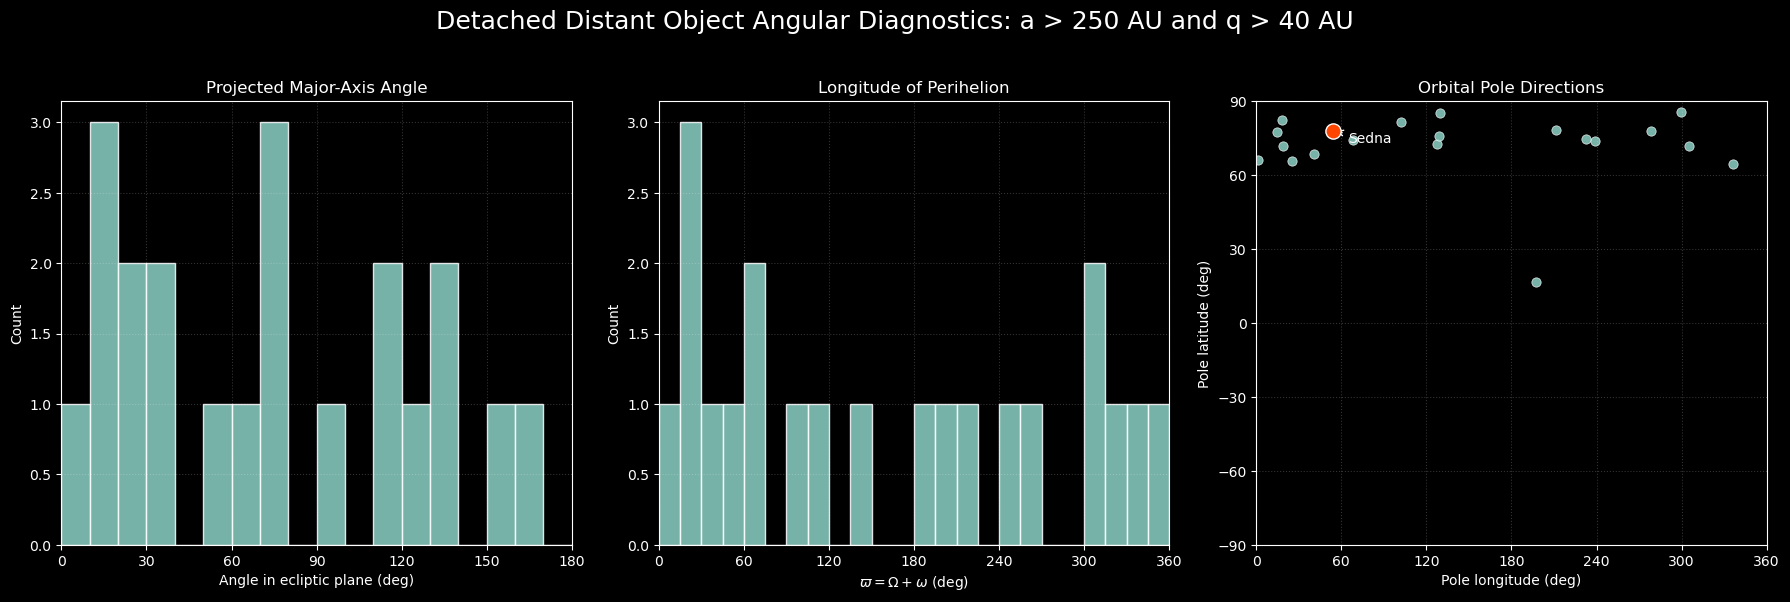

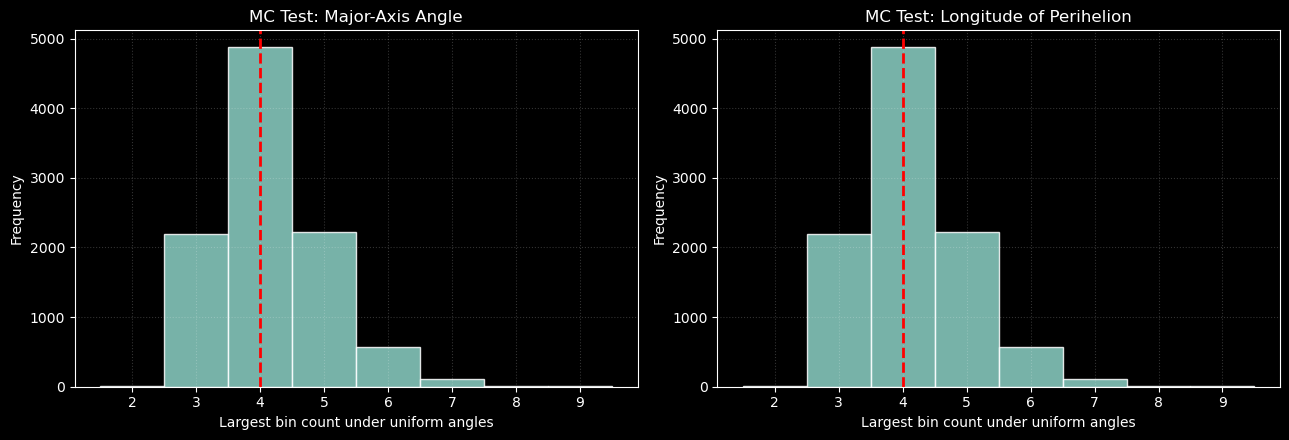

In [15]:
subset_extreme = plot_df[
    (plot_df["a"] > 250) &
    (plot_df["a"] * (1.0 - plot_df["e"]) > 40)
].copy()

diagnostics_extreme = analyse_ddo_subset(
    df=subset_extreme,
    subset_name="a > 250 AU and q > 40 AU",
    highlight_name="Sedna",
    n_sim=10000,
)